# Predicción de Ventas - SiempreTuAmigo

En este notebook haremos una predicción simple de ventas usando los datos históricos de la tienda.

La idea es ver cómo han cambiado las ventas con los años y usar esa tendencia para estimar el valor del año 2026.

Al final tendrás: la predicción para 2026, el coeficiente, el intercepto y una gráfica para entenderlo de forma visual.

## Importar librerías necesarias

Primero importamos las librerías que vamos a usar.

- `pandas` para leer y organizar los datos
- `numpy` para manejar arreglos numéricos
- `matplotlib` para hacer la gráfica
- `LinearRegression` para entrenar el modelo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Cargar los datos

En este paso abrimos el archivo CSV con las ventas por año.

Es importante revisar que los datos se carguen bien, porque con estos valores se entrena todo el modelo.

In [2]:
# Cargar datos desde el archivo CSV
datos = pd.read_csv('datosVentas.csv')

# Mostrar los datos cargados
print("Datos de ventas:")
print(datos)
print(f"\nTotal de registros: {len(datos)}")

Datos de ventas:
    Año  Ventas
0  2018       7
1  2019      22
2  2020      25
3  2021      32
4  2022      49
5  2023      53
6  2024      60
7  2025      72

Total de registros: 8


## Preparar los datos para el modelo

Aquí separamos los datos en dos partes: los años (X) y las ventas (y). El modelo necesita que estén organizados de esta manera para poder aprender la relación entre los años y las ventas.

In [3]:
# Preparar X (años) como matriz 2D y y (ventas) como vector
X = datos[['Año']].values
y = datos['Ventas'].values

print(f"X (Años): {X.flatten()}")
print(f"y (Ventas): {y}")

X (Años): [2018 2019 2020 2021 2022 2023 2024 2025]
y (Ventas): [ 7 22 25 32 49 53 60 72]


## Crear y entrenar el modelo de regresión lineal

El modelo de regresión lineal es como una línea recta que se ajusta a nuestros datos. Aquí lo creamos y lo entrenamos con los datos históricos para que aprenda el patrón de crecimiento de las ventas.

Lo importante son dos números:
- **Coeficiente**: cuánto aumentan las ventas cada año
- **Intercepto**: el valor inicial

In [4]:
# Crear el modelo de regresión lineal
modelo = LinearRegression()

# Entrenar el modelo
modelo.fit(X, y)

# Obtener el coeficiente y el intercepto
coeficiente = modelo.coef_[0]
intercepto = modelo.intercept_

print(f"Coeficiente (pendiente): {coeficiente:.4f}")
print(f"Intercepto: {intercepto:.4f}")
print(f"\nEcuación del modelo: y = {coeficiente:.4f}*x + {intercepto:.4f}")

Coeficiente (pendiente): 8.8810
Intercepto: -17912.8452

Ecuación del modelo: y = 8.8810*x + -17912.8452


##  Realizar predicción para el año 2026

Ahora usamos el modelo entrenado para predecir cuántas ventas tendrá la tienda en el año 2026. Simplemente le decimos al modelo "¿cuál será el valor para el año 2026?" y él nos da la respuesta.

In [5]:
# Realizar predicción para el año 2026
año_prediccion = 2026
X_prediccion = np.array([[año_prediccion]])
prediccion_2026 = modelo.predict(X_prediccion)[0]

print(f"Predicción de ventas para el año {año_prediccion}: {prediccion_2026:.2f}")

Predicción de ventas para el año 2026: 79.96


## 6. Evaluar el modelo

Aquí verificamos qué tan bien funciona nuestro modelo. El R² es un número entre 0 y 1 que nos dice si la línea recta se ajusta bien a los datos. Un R² cercano a 1 significa que el modelo es muy bueno.

In [6]:
# Calcular predicciones para los datos de entrenamiento
y_pred = modelo.predict(X)

# Calcular el coeficiente de determinación (R²)
r2 = r2_score(y, y_pred)

print(f"Coeficiente de determinación (R²): {r2:.4f}")
print(f"\nEl modelo explica el {r2*100:.2f}% de la variabilidad en los datos")

Coeficiente de determinación (R²): 0.9812

El modelo explica el 98.12% de la variabilidad en los datos


## 7. Visualizar el modelo y la predicción

Hacemos una gráfica para ver claramente la relación entre los años y las ventas. Los puntos azules son los datos reales de la tienda, y la línea roja es la predicción del modelo. También mostramos con una estrella roja dónde será la predicción para 2026.

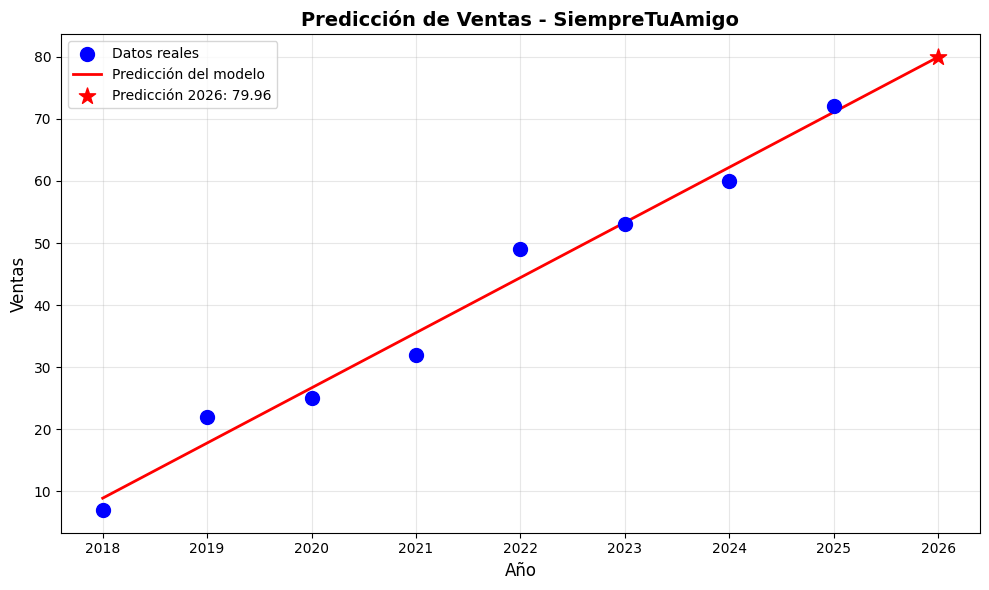

In [7]:
# Crear la gráfica
plt.figure(figsize=(10, 6))

# Graficar los datos reales
plt.scatter(datos['Año'], datos['Ventas'], color='blue', s=100, label='Datos reales', zorder=3)

# Crear puntos para la línea de predicción
años_linea = np.array([datos['Año'].min(), año_prediccion])
ventas_linea = modelo.predict(años_linea.reshape(-1, 1))

# Graficar la línea de predicción
plt.plot(años_linea, ventas_linea, color='red', linewidth=2, label='Predicción del modelo')

# Señalar el punto de predicción para 2026
plt.scatter([año_prediccion], [prediccion_2026], color='red', s=150, marker='*', zorder=4, label=f'Predicción 2026: {prediccion_2026:.2f}')

# Configurar la gráfica
plt.xlabel('Año', fontsize=12)
plt.ylabel('Ventas', fontsize=12)
plt.title('Predicción de Ventas - SiempreTuAmigo', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(range(2018, 2027, 1))
plt.tight_layout()

plt.show()

## Resumen de resultados

En este laboratorio se obtiene:

1. La predicción de ventas para 2026.
2. El coeficiente del modelo (`modelo.coef_`).
3. El intercepto del modelo (`modelo.intercept_`).
4. La gráfica con los datos reales y la línea de predicción.

Los valores numéricos se muestran en las salidas de las celdas anteriores.